In [73]:
import pandas as pd

ccc = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\CCC.csv")

print(ccc.shape)
print(ccc.columns.tolist())

(4434, 40)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'ass_8_date', 'ass_8_score', 'ass_9_date', 'ass_9_score', 'clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_page', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [75]:
demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                 'num_of_prev_attempts', 'studied_credits', 'disability']

assessment_cols = [f'ass_{i}_score' for i in range(1, 10)]

click_cols = ['clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent',
              'clicks_page', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']

selected_cols = demographics + assessment_cols + click_cols + ['final_result']

ccc_sel = ccc[selected_cols].copy()
print(ccc_sel.shape)
ccc_sel.head()

(4434, 27)


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,...,clicks_forumng,clicks_homepage,clicks_oucollaborate,clicks_oucontent,clicks_page,clicks_quiz,clicks_resource,clicks_subpage,clicks_url,final_result
0,F,West Midlands Region,A Level or Equivalent,20-30%,0-35,0,30,N,NaN,NaN,...,1.0,67.0,0.0,3.0,0.0,133.0,44.0,79.0,1.0,Fail
1,M,East Anglian Region,A Level or Equivalent,50-60%,0-35,0,90,N,92.0,97.0,...,21.0,224.0,0.0,92.0,11.0,2135.0,88.0,288.0,8.0,Distinction
2,M,East Anglian Region,HE Qualification,40-50%,0-35,0,60,N,100.0,87.0,...,173.0,234.0,0.0,12.0,1.0,328.0,156.0,116.0,7.0,Pass
3,M,North Region,HE Qualification,0-10%,35-55,0,30,N,NaN,NaN,...,10.0,53.0,0.0,7.0,0.0,27.0,24.0,46.0,7.0,Withdrawn
4,M,Ireland,A Level or Equivalent,NaN,35-55,0,30,N,90.0,68.0,...,14.0,133.0,0.0,32.0,0.0,178.0,30.0,73.0,5.0,Pass


In [77]:
print("imd_band unique values:")
print(ccc_sel['imd_band'].unique())
print()
print("imd_band NaN count:", ccc_sel['imd_band'].isna().sum())
print()
print("NaN counts - assessment scores:")
print(ccc_sel[assessment_cols].isna().sum())
print()
print("NaN counts - click columns:")
print(ccc_sel[click_cols].isna().sum())

imd_band unique values:
['20-30%' '50-60%' '40-50%' '0-10%' nan '90-100%' '60-70%' '80-90%'
 '10-20' '30-40%' '70-80%']

imd_band NaN count: 254

NaN counts - assessment scores:
ass_1_score    2074
ass_2_score    2619
ass_3_score    2858
ass_4_score    2937
ass_5_score    1171
ass_6_score    1871
ass_7_score    2294
ass_8_score    2634
ass_9_score    2519
dtype: int64

NaN counts - click columns:
clicks_forumng          451
clicks_homepage         451
clicks_oucollaborate    451
clicks_oucontent        451
clicks_page             451
clicks_quiz             451
clicks_resource         451
clicks_subpage          451
clicks_url              451
dtype: int64


In [79]:
# Fix imd_band missing % bug
ccc_sel['imd_band'] = ccc_sel['imd_band'].replace('10-20', '10-20%')

# Mode-fill imd_band NaN
imd_mode = ccc_sel['imd_band'].mode()[0]
print("imd_band mode:", imd_mode)
ccc_sel['imd_band'] = ccc_sel['imd_band'].fillna(imd_mode)

# Confirm fix
print(ccc_sel['imd_band'].unique())

# Sanity check: are the 451 click-NaN students the same across all 9 columns?
click_nan_mask = ccc_sel[click_cols].isna()
same_students = (click_nan_mask.sum(axis=1).isin([0, 9])).all()
print("All-or-nothing NaN pattern across clicks:", same_students)

# Impute: scores NaN -> -1, clicks NaN -> 0
ccc_sel[assessment_cols] = ccc_sel[assessment_cols].fillna(-1)
ccc_sel[click_cols] = ccc_sel[click_cols].fillna(0)

print(ccc_sel.isna().sum().sum())  # should be 0 now

imd_band mode: 20-30%
['20-30%' '50-60%' '40-50%' '0-10%' '90-100%' '60-70%' '80-90%' '10-20%'
 '30-40%' '70-80%']
All-or-nothing NaN pattern across clicks: True
0


In [81]:
# Ordinal encodings
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
ccc_sel['final_result'] = ccc_sel['final_result'].map(final_result_map)

highest_ed_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                     'HE Qualification', 'Post Graduate Qualification']
highest_ed_map = {v: i for i, v in enumerate(highest_ed_order)}
ccc_sel['highest_education'] = ccc_sel['highest_education'].map(highest_ed_map)

imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%',
             '60-70%', '70-80%', '80-90%', '90-100%']
imd_map = {v: i for i, v in enumerate(imd_order)}
ccc_sel['imd_band'] = ccc_sel['imd_band'].map(imd_map)

age_band_order = ['0-35', '35-55', '55<=']
age_band_map = {v: i for i, v in enumerate(age_band_order)}
ccc_sel['age_band'] = ccc_sel['age_band'].map(age_band_map)

# Binary encodings
ccc_sel['gender'] = ccc_sel['gender'].map({'M': 0, 'F': 1})
ccc_sel['disability'] = ccc_sel['disability'].map({'N': 0, 'Y': 1})

# Label encoding for region
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ccc_sel['region'] = le.fit_transform(ccc_sel['region'])

# Verify no NaN introduced by mapping (catches unexpected category values)
print(ccc_sel.isna().sum().sum())
print(ccc_sel.dtypes)

0
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
ass_1_score             float64
ass_2_score             float64
ass_3_score             float64
ass_4_score             float64
ass_5_score             float64
ass_6_score             float64
ass_7_score             float64
ass_8_score             float64
ass_9_score             float64
clicks_forumng          float64
clicks_homepage         float64
clicks_oucollaborate    float64
clicks_oucontent        float64
clicks_page             float64
clicks_quiz             float64
clicks_resource         float64
clicks_subpage          float64
clicks_url              float64
final_result              int64
dtype: object


In [83]:
for col in click_cols:
    nonzero = (ccc_sel[col] != 0).sum()
    unique_vals = ccc_sel[col].nunique()
    print(f"{col}: {nonzero} nonzero / {unique_vals} unique values")

clicks_forumng: 3295 nonzero / 666 unique values
clicks_homepage: 3979 nonzero / 706 unique values
clicks_oucollaborate: 1209 nonzero / 59 unique values
clicks_oucontent: 3382 nonzero / 612 unique values
clicks_page: 1453 nonzero / 20 unique values
clicks_quiz: 3734 nonzero / 1394 unique values
clicks_resource: 3848 nonzero / 302 unique values
clicks_subpage: 3801 nonzero / 396 unique values
clicks_url: 3574 nonzero / 74 unique values


In [85]:
# Sum raw click counts into total_clicks
ccc_sel['total_clicks'] = ccc_sel[click_cols].sum(axis=1)

# Drop individual click columns
ccc_sel = ccc_sel.drop(columns=click_cols)

# Quartile-bin assessments and total_clicks
bin_cols = assessment_cols + ['total_clicks']

for col in bin_cols:
    binned = pd.qcut(ccc_sel[col], q=4, duplicates='drop')
    n_bins = binned.nunique()
    print(f"{col}: {n_bins} bins")
    ccc_sel[col] = binned.cat.codes

print()
print("Final shape:", ccc_sel.shape)
print(ccc_sel.columns.tolist())

ass_1_score: 3 bins
ass_2_score: 2 bins
ass_3_score: 2 bins
ass_4_score: 2 bins
ass_5_score: 3 bins
ass_6_score: 3 bins
ass_7_score: 2 bins
ass_8_score: 2 bins
ass_9_score: 2 bins
total_clicks: 4 bins

Final shape: (4434, 19)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'final_result', 'total_clicks']


In [87]:
for i, col in enumerate([f'ass_{i}_score' for i in range(1, 10)], 1):
    non_sub = (ccc[f'ass_{i}_score'].isna()).sum()
    pct = non_sub / len(ccc) * 100
    print(f"ass_{i}: {non_sub} non-submitted ({pct:.1f}%)")

ass_1: 2074 non-submitted (46.8%)
ass_2: 2619 non-submitted (59.1%)
ass_3: 2858 non-submitted (64.5%)
ass_4: 2937 non-submitted (66.2%)
ass_5: 1171 non-submitted (26.4%)
ass_6: 1871 non-submitted (42.2%)
ass_7: 2294 non-submitted (51.7%)
ass_8: 2634 non-submitted (59.4%)
ass_9: 2519 non-submitted (56.8%)


In [89]:
print(ccc_sel['region'].name)  # placeholder, ignoring
print(ccc.groupby('code_presentation')[[f'ass_{i}_score' for i in range(1,10)]].apply(lambda d: d.isna().mean() * 100))

region
                   ass_1_score  ass_2_score  ass_3_score  ass_4_score  \
code_presentation                                                       
2014B                51.704545    64.411157    68.388430    69.989669   
2014J                42.954363    54.923939    61.409127    63.330665   

                   ass_5_score  ass_6_score  ass_7_score  ass_8_score  \
code_presentation                                                       
2014B                30.475207    46.849174    56.663223    63.533058   
2014J                23.258607    38.590873    47.918335    56.204964   

                   ass_9_score  
code_presentation               
2014B                61.415289  
2014J                53.242594  


In [91]:
print("Final CCC variable set:", ccc_sel.shape)
print(ccc_sel.columns.tolist())
print()
print(ccc_sel.dtypes)
print()
ccc_sel.head()

Final CCC variable set: (4434, 19)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'final_result', 'total_clicks']

gender                  int64
region                  int64
highest_education       int64
imd_band                int64
age_band                int64
num_of_prev_attempts    int64
studied_credits         int64
disability              int64
ass_1_score              int8
ass_2_score              int8
ass_3_score              int8
ass_4_score              int8
ass_5_score              int8
ass_6_score              int8
ass_7_score              int8
ass_8_score              int8
ass_9_score              int8
final_result            int64
total_clicks             int8
dtype: object



,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,ass_3_score,ass_4_score,ass_5_score,ass_6_score,ass_7_score,ass_8_score,ass_9_score,final_result,total_clicks
0,1,11,2,2,0,0,30,0,0,0,0,0,0,0,0,0,0,1,1
1,0,0,2,5,0,0,90,0,2,1,1,1,2,2,1,1,1,3,3
2,0,0,3,4,0,0,60,0,2,1,1,1,0,1,1,1,1,2,2
3,0,4,3,0,1,0,30,0,0,0,0,0,0,0,0,0,0,0,1
4,0,2,2,2,1,0,30,0,2,0,0,0,1,2,0,0,0,2,1


In [93]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
import numpy as np

data = ccc_sel.values.astype(float)
node_names = ccc_sel.columns.tolist()

bk = BackgroundKnowledge()

# Rule 1: course-time variables cannot cause demographics
course_time_vars = [f'ass_{i}_score' for i in range(1, 10)] + ['total_clicks', 'final_result']
demo_vars = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
             'num_of_prev_attempts', 'studied_credits', 'disability']

# (forbidden edges will be added via add_forbidden_by_node below once GraphNodes are built)

In [95]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import numpy as np

data = ccc_sel.values.astype(float)
node_names = ccc_sel.columns.tolist()

# Build GraphNode objects keyed by column name
nodes = {name: GraphNode(name) for name in node_names}

assessment_cols_ccc = [f'ass_{i}_score' for i in range(1, 10)]
demo_vars = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
             'num_of_prev_attempts', 'studied_credits', 'disability']
course_time_vars = assessment_cols_ccc + ['total_clicks', 'final_result']

bk = BackgroundKnowledge()

# Rule 1: course-time variables cannot cause demographics
for ct in course_time_vars:
    for d in demo_vars:
        bk.add_forbidden_by_node(nodes[ct], nodes[d])

# Rule 2: nothing can cause gender (pure root)
for name in node_names:
    if name != 'gender':
        bk.add_forbidden_by_node(nodes[name], nodes['gender'])

# Rule 3: assessments must respect sequential order (ass_j can't cause ass_i if j > i)
for i in range(1, 10):
    for j in range(1, 10):
        if j > i:
            bk.add_forbidden_by_node(nodes[f'ass_{j}_score'], nodes[f'ass_{i}_score'])

# Rule 4: course-time variables cannot cause studied_credits/num_of_prev_attempts
for ct in course_time_vars:
    bk.add_forbidden_by_node(nodes[ct], nodes['studied_credits'])
    bk.add_forbidden_by_node(nodes[ct], nodes['num_of_prev_attempts'])

# Rule 5: final_result cannot cause any assessment score
for a in assessment_cols_ccc:
    bk.add_forbidden_by_node(nodes['final_result'], nodes[a])

# Rule 6: assessment scores cannot cause total_clicks
for a in assessment_cols_ccc:
    bk.add_forbidden_by_node(nodes[a], nodes['total_clicks'])

# Run PC with gsq
cg = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("PC complete.")
print("Number of edges:", cg.G.get_num_edges())

  0%|          | 0/19 [00:00<?, ?it/s]

PC complete.
Number of edges: 43


In [119]:
# Rule 7 (NEW, CCC-specific so far): final_result cannot cause total_clicks
bk.add_forbidden_by_node(nodes['final_result'], nodes['total_clicks'])

# Rerun PC with all 7 rules
cg = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("PC complete (7 BK rules).")
print("Number of edges:", cg.G.get_num_edges())

  0%|          | 0/19 [00:00<?, ?it/s]

PC complete (7 BK rules).
Number of edges: 43


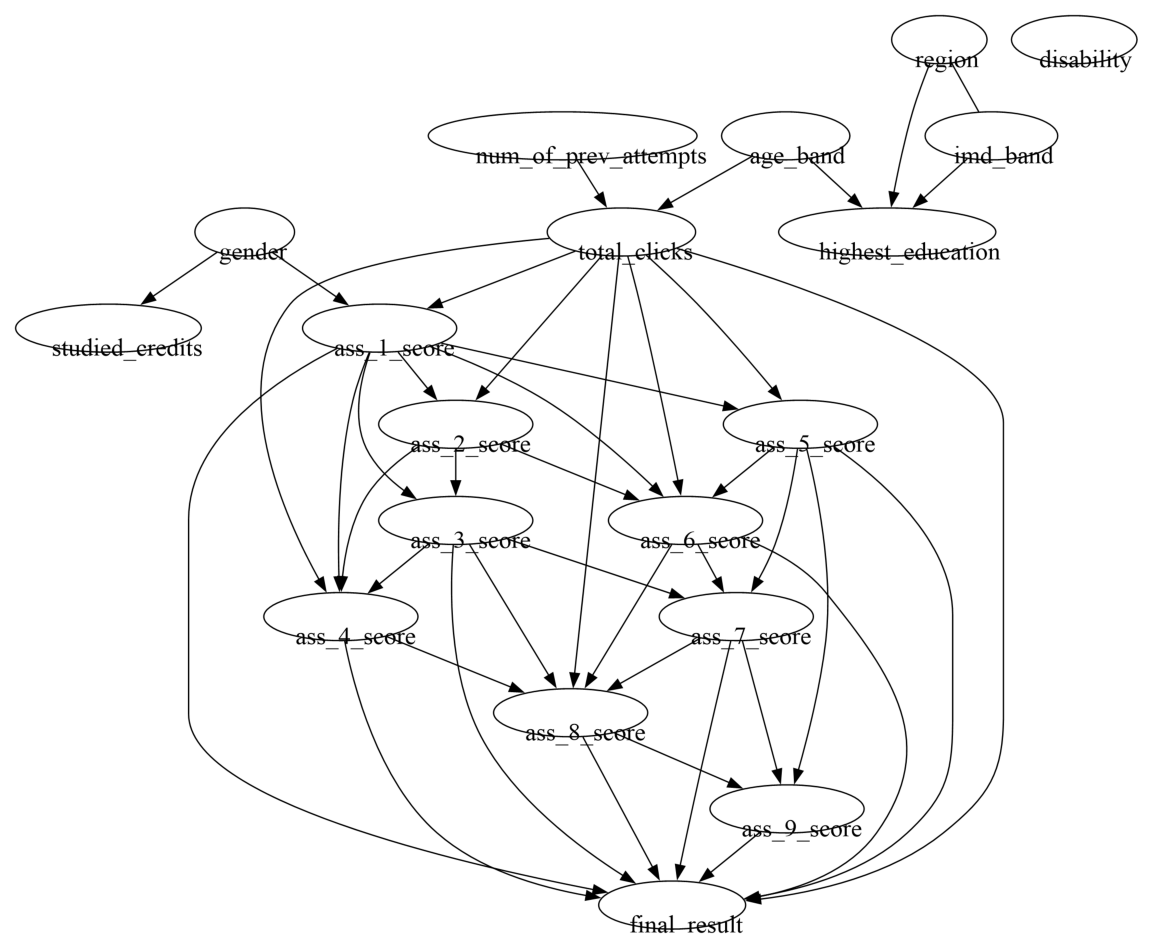

In [121]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

pyd = GraphUtils.to_pydot(cg.G, labels=node_names)
png_data = pyd.create_png(prog=dot_path)

img = mpimg.imread(io.BytesIO(png_data))
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

In [123]:
edges = cg.G.get_graph_edges()
for edge in edges:
    print(edge)

gender --> studied_credits
gender --> ass_1_score
region --> highest_education
region --- imd_band
imd_band --> highest_education
age_band --> highest_education
age_band --> total_clicks
num_of_prev_attempts --> total_clicks
ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
ass_1_score --> ass_5_score
ass_1_score --> ass_6_score
ass_1_score --> final_result
total_clicks --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
ass_2_score --> ass_6_score
total_clicks --> ass_2_score
ass_3_score --> ass_4_score
ass_3_score --> ass_7_score
ass_3_score --> ass_8_score
ass_3_score --> final_result
ass_4_score --> ass_8_score
ass_4_score --> final_result
total_clicks --> ass_4_score
ass_5_score --> ass_6_score
ass_5_score --> ass_7_score
ass_5_score --> ass_9_score
ass_5_score --> final_result
total_clicks --> ass_5_score
ass_6_score --> ass_7_score
ass_6_score --> ass_8_score
ass_6_score --> final_result
total_clicks --> ass_6_score
ass_7_sco

# GES -- useless

In [105]:
from causallearn.search.ScoreBased.GES import ges

ges_result = ges(data, score_func='local_score_BDeu')

cg_ges = ges_result['G']
print("Number of edges (GES):", cg_ges.get_num_edges())

Number of edges (GES): 29


In [113]:
ges_edges = cg_ges.get_graph_edges()
for edge in ges_edges:
    print(edge)

X8 --> X1
X3 --> X2
X3 --> X5
X3 --> X8
X17 --> X3
X17 --> X6
X10 --> X9
X9 --> X13
X14 --> X9
X19 --> X9
X11 --> X10
X12 --> X10
X14 --> X10
X11 --- X12
X11 --- X15
X11 --- X18
X12 --> X16
X12 --- X18
X14 --> X13
X14 --- X15
X14 --- X18
X14 --- X19
X15 --> X16
X15 --> X17
X15 --- X18
X16 --> X17
X18 --> X16
X18 --> X17
X18 --- X19


In [115]:
idx_to_name = {i+1: name for i, name in enumerate(node_names)}

for edge in ges_edges:
    parts = str(edge).split()
    n1 = idx_to_name[int(parts[0][1:])]
    n2 = idx_to_name[int(parts[2][1:])]
    arrow = parts[1]
    print(f"{n1} {arrow} {n2}")

disability --> gender
highest_education --> region
highest_education --> age_band
highest_education --> disability
ass_9_score --> highest_education
ass_9_score --> num_of_prev_attempts
ass_2_score --> ass_1_score
ass_1_score --> ass_5_score
ass_6_score --> ass_1_score
total_clicks --> ass_1_score
ass_3_score --> ass_2_score
ass_4_score --> ass_2_score
ass_6_score --> ass_2_score
ass_3_score --- ass_4_score
ass_3_score --- ass_7_score
ass_3_score --- final_result
ass_4_score --> ass_8_score
ass_4_score --- final_result
ass_6_score --> ass_5_score
ass_6_score --- ass_7_score
ass_6_score --- final_result
ass_6_score --- total_clicks
ass_7_score --> ass_8_score
ass_7_score --> ass_9_score
ass_7_score --- final_result
ass_8_score --> ass_9_score
final_result --> ass_8_score
final_result --> ass_9_score
final_result --- total_clicks


In [117]:
import pydot

pyd_ges = pydot.Dot(graph_type='digraph')
pyd_ges.set_rankdir('TB')
pyd_ges.set_nodesep(0.5)
pyd_ges.set_ranksep(0.8)
pyd_ges.set_splines('spline')

for name in node_names:
    node = pydot.Node(name, fontsize='11', fixedsize='false', margin='0.15,0.08')
    pyd_ges.add_node(node)

for edge in ges_edges:
    parts = str(edge).split()
    n1 = idx_to_name[int(parts[0][1:])]
    n2 = idx_to_name[int(parts[2][1:])]
    arrow = parts[1]
    if arrow == '-->':
        pyd_ges.add_edge(pydot.Edge(n1, n2, dir='forward'))
    else:
        pyd_ges.add_edge(pydot.Edge(n1, n2, dir='none'))

png_data = pyd_ges.create_png(prog=dot_path)
with open(r"C:\Users\Disha Sharma\Desktop\Causal_AI\CCC_GES_graph.png", "wb") as f:
    f.write(png_data)

print("Saved")

Saved


# domain specific DAGs

## Student info vs final_result

In [135]:
demographics_ccc = ['gender','region','highest_education','imd_band','age_band',
                     'num_of_prev_attempts','studied_credits','disability']
assessment_cols_ccc = [f'ass_{i}_score' for i in range(1,10)]
click_cols_ccc = ['clicks_forumng','clicks_homepage','clicks_oucollaborate','clicks_oucontent',
                   'clicks_page','clicks_quiz','clicks_resource','clicks_subpage','clicks_url']

df_sel = df[demographics_ccc + assessment_cols_ccc + click_cols_ccc + ['final_result']].copy()

print(df_sel.shape)

KeyError: "['clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_page', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url'] not in index"

In [137]:
print([c for c in df.columns if 'click' in c.lower()])

['total_clicks', 'total_clicks_binned']


In [139]:
print(list(df.columns))

['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'ass_8_date', 'ass_8_score', 'ass_9_date', 'ass_9_score', 'total_clicks', 'ass_1_score_binned', 'ass_2_score_binned', 'ass_3_score_binned', 'ass_4_score_binned', 'ass_5_score_binned', 'ass_6_score_binned', 'ass_7_score_binned', 'ass_8_score_binned', 'ass_9_score_binned', 'total_clicks_binned', 'ass_1_score_cat', 'ass_2_score_cat', 'ass_3_score_cat', 'ass_4_score_cat', 'ass_5_score_cat', 'ass_6_score_cat', 'ass_7_score_cat', 'ass_8_score_cat', 'ass_9_score_cat']


In [141]:
print(df[['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'final_result']].dtypes)
print(df[['gender', 'highest_education', 'final_result']].head(3))

gender               int64
region               int64
highest_education    int64
imd_band             int64
age_band             int64
disability           int64
final_result         int64
dtype: object
   gender  highest_education  final_result
0       1                  2             1
1       0                  2             3
2       0                  3             2


In [143]:
demo_cols_ccc = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                  'num_of_prev_attempts', 'studied_credits', 'disability']

dag1_data_ccc = df[demo_cols_ccc + ['final_result']].copy()

print(dag1_data_ccc.shape)
print(dag1_data_ccc.isnull().sum())

(4434, 9)
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64


In [145]:
node_names_dag1_ccc = list(dag1_data_ccc.columns)
nodes_dag1_ccc = [GraphNode(name) for name in node_names_dag1_ccc]

bk1_ccc = BackgroundKnowledge()

gender_node_ccc = nodes_dag1_ccc[node_names_dag1_ccc.index('gender')]
final_result_node_ccc = nodes_dag1_ccc[node_names_dag1_ccc.index('final_result')]

# Rule 2: nothing causes gender (root)
for n in nodes_dag1_ccc:
    if n != gender_node_ccc:
        bk1_ccc.add_forbidden_by_node(n, gender_node_ccc)

# Rule 1 (generalized): final_result cannot cause any demographic
for n in nodes_dag1_ccc:
    if n != final_result_node_ccc:
        bk1_ccc.add_forbidden_by_node(final_result_node_ccc, n)

# Sanity check
highest_education_node_ccc = nodes_dag1_ccc[node_names_dag1_ccc.index('highest_education')]
print("highest_education -> gender forbidden:", bk1_ccc.is_forbidden(highest_education_node_ccc, gender_node_ccc))
print("final_result -> studied_credits forbidden:", bk1_ccc.is_forbidden(final_result_node_ccc, nodes_dag1_ccc[node_names_dag1_ccc.index('studied_credits')]))

highest_education -> gender forbidden: True
final_result -> studied_credits forbidden: True


In [147]:
data1_ccc = dag1_data_ccc.to_numpy()

cg1_ccc = pc(data1_ccc, alpha=0.05, indep_test='gsq', background_knowledge=bk1_ccc, node_names=node_names_dag1_ccc)

print("Number of edges:", cg1_ccc.G.get_num_edges())

  0%|          | 0/9 [00:00<?, ?it/s]

Number of edges: 9


In [149]:
for edge in cg1_ccc.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

gender [TAIL] -- [ARROW] studied_credits
region [TAIL] -- [ARROW] highest_education
region [TAIL] -- [TAIL] imd_band
region [TAIL] -- [ARROW] final_result
imd_band [TAIL] -- [ARROW] highest_education
age_band [TAIL] -- [ARROW] highest_education
highest_education [TAIL] -- [ARROW] final_result
imd_band [TAIL] -- [ARROW] final_result
studied_credits [TAIL] -- [ARROW] final_result


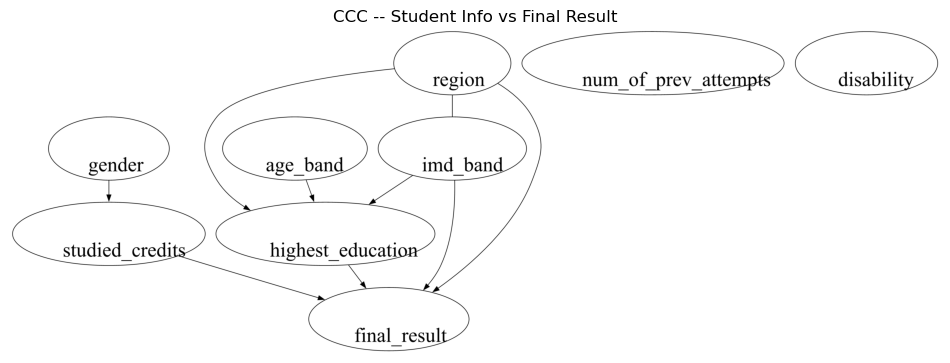

In [199]:
pyd1_ccc = GraphUtils.to_pydot(cg1_ccc.G, labels=node_names_dag1_ccc)

for node in pyd1_ccc.get_nodes():
    node.set_fontsize('25')
    node.set_fixedsize('false')
    node.set_margin('0.5,0.30')

png_bytes1_ccc = pyd1_ccc.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\CCC_DAG1_studentinfo_vs_finalresult.png", "wb") as f:
    f.write(png_bytes1_ccc)

img1_ccc = mpimg.imread(io.BytesIO(png_bytes1_ccc), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img1_ccc)
plt.axis('off')
plt.title("CCC -- Student Info vs Final Result")
plt.show()

## assessments vs final_result

In [164]:
ass_cols_ccc_binned = [f'ass_{i}_score_binned' for i in range(1, 10)]

dag2_data_ccc = df[ass_cols_ccc_binned + ['final_result']].copy()

print(dag2_data_ccc.shape)
print(dag2_data_ccc.nunique())

(4434, 10)
ass_1_score_binned    3
ass_2_score_binned    2
ass_3_score_binned    2
ass_4_score_binned    2
ass_5_score_binned    3
ass_6_score_binned    3
ass_7_score_binned    2
ass_8_score_binned    2
ass_9_score_binned    2
final_result          4
dtype: int64


In [166]:
node_names_dag2_ccc = list(dag2_data_ccc.columns)
nodes_dag2_ccc = [GraphNode(name) for name in node_names_dag2_ccc]

bk2_ccc = BackgroundKnowledge()

final_result_node2_ccc = nodes_dag2_ccc[node_names_dag2_ccc.index('final_result')]

# Rule 5: final_result cannot cause any assessment
for n in nodes_dag2_ccc:
    if n != final_result_node2_ccc:
        bk2_ccc.add_forbidden_by_node(final_result_node2_ccc, n)

# Rule 3: sequential order -- ass_j cannot cause ass_i if j > i
for j in range(1, 10):
    for i in range(1, j):
        node_j = nodes_dag2_ccc[node_names_dag2_ccc.index(f'ass_{j}_score_binned')]
        node_i = nodes_dag2_ccc[node_names_dag2_ccc.index(f'ass_{i}_score_binned')]
        bk2_ccc.add_forbidden_by_node(node_j, node_i)

# Sanity check
ass1_node_ccc = nodes_dag2_ccc[node_names_dag2_ccc.index('ass_1_score_binned')]
ass7_node_ccc = nodes_dag2_ccc[node_names_dag2_ccc.index('ass_7_score_binned')]
print("ass_7 -> ass_1 forbidden:", bk2_ccc.is_forbidden(ass7_node_ccc, ass1_node_ccc))
print("final_result -> ass_1 forbidden:", bk2_ccc.is_forbidden(final_result_node2_ccc, ass1_node_ccc))

ass_7 -> ass_1 forbidden: True
final_result -> ass_1 forbidden: True


In [168]:
data2_ccc = dag2_data_ccc.to_numpy()

cg2_ccc = pc(data2_ccc, alpha=0.05, indep_test='gsq', background_knowledge=bk2_ccc, node_names=node_names_dag2_ccc)

print("Number of edges:", cg2_ccc.G.get_num_edges())

  0%|          | 0/10 [00:00<?, ?it/s]

Number of edges: 29


In [170]:
for edge in cg2_ccc.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

ass_1_score_binned [TAIL] -- [ARROW] ass_2_score_binned
ass_1_score_binned [TAIL] -- [ARROW] ass_3_score_binned
ass_1_score_binned [TAIL] -- [ARROW] ass_4_score_binned
ass_1_score_binned [TAIL] -- [ARROW] ass_5_score_binned
ass_1_score_binned [TAIL] -- [ARROW] ass_6_score_binned
ass_1_score_binned [TAIL] -- [ARROW] final_result
ass_2_score_binned [TAIL] -- [ARROW] ass_3_score_binned
ass_2_score_binned [TAIL] -- [ARROW] ass_4_score_binned
ass_2_score_binned [TAIL] -- [ARROW] ass_6_score_binned
ass_2_score_binned [TAIL] -- [ARROW] final_result
ass_3_score_binned [TAIL] -- [ARROW] ass_4_score_binned
ass_3_score_binned [TAIL] -- [ARROW] ass_7_score_binned
ass_3_score_binned [TAIL] -- [ARROW] ass_8_score_binned
ass_3_score_binned [TAIL] -- [ARROW] final_result
ass_4_score_binned [TAIL] -- [ARROW] ass_8_score_binned
ass_4_score_binned [TAIL] -- [ARROW] final_result
ass_5_score_binned [TAIL] -- [ARROW] ass_6_score_binned
ass_5_score_binned [TAIL] -- [ARROW] ass_7_score_binned
ass_5_score_binn

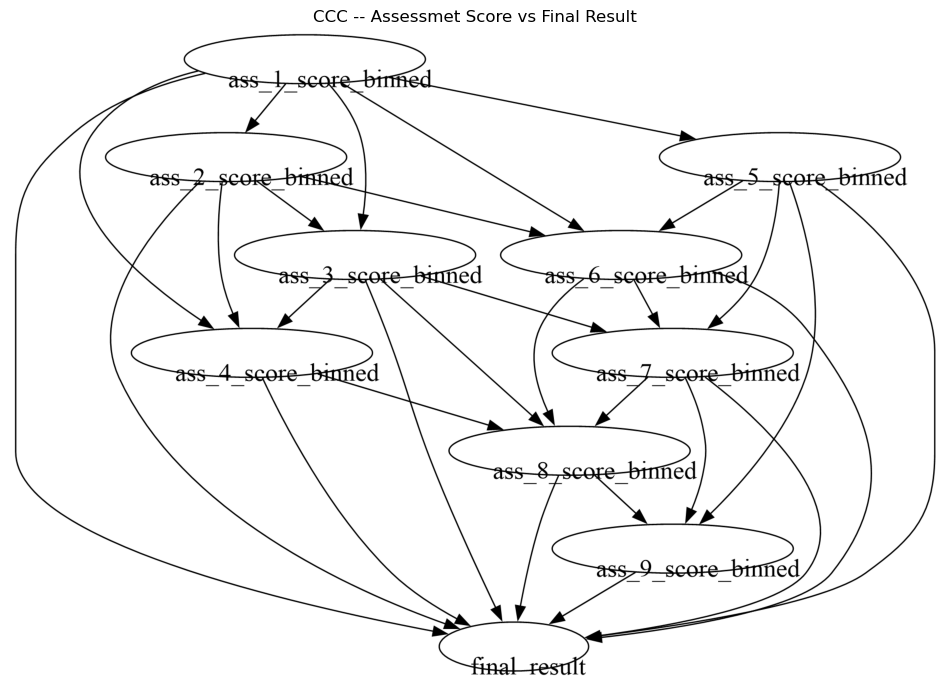

In [197]:
pyd2_ccc = GraphUtils.to_pydot(cg2_ccc.G, labels=node_names_dag2_ccc)

for node in pyd1_ccc.get_nodes():
    node.set_fontsize('20')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.30')

png_bytes2_ccc = pyd2_ccc.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\CCC_DAG2_assessments_vs_finalresult.png", "wb") as f:
    f.write(png_bytes2_ccc)

img1_ccc = mpimg.imread(io.BytesIO(png_bytes2_ccc), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img1_ccc)
plt.axis('off')
plt.title("CCC -- Assessmet Score vs Final Result")
plt.show()

## individual clicks vs final_result

In [185]:
df_raw_ccc = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\CCC.csv")

raw_click_cols_ccc = ['clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent',
                       'clicks_page', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']

clicks_raw_ccc = df_raw_ccc[raw_click_cols_ccc].fillna(0)

for col in raw_click_cols_ccc:
    print(col, "nonzero:", (clicks_raw_ccc[col] > 0).sum(), "unique:", clicks_raw_ccc[col].nunique())

print(clicks_raw_ccc.shape)

clicks_forumng nonzero: 3295 unique: 666
clicks_homepage nonzero: 3979 unique: 706
clicks_oucollaborate nonzero: 1209 unique: 59
clicks_oucontent nonzero: 3382 unique: 612
clicks_page nonzero: 1453 unique: 20
clicks_quiz nonzero: 3734 unique: 1394
clicks_resource nonzero: 3848 unique: 302
clicks_subpage nonzero: 3801 unique: 396
clicks_url nonzero: 3574 unique: 74
(4434, 9)


In [187]:
dag3_data_ccc = clicks_raw_ccc.copy()

for col in raw_click_cols_ccc:
    dag3_data_ccc[col] = pd.qcut(dag3_data_ccc[col], q=4, labels=False, duplicates='drop')

dag3_data_ccc['final_result'] = df['final_result'].values

print(dag3_data_ccc.shape)
for col in dag3_data_ccc.columns:
    print(col, dag3_data_ccc[col].nunique())

(4434, 10)
clicks_forumng 3
clicks_homepage 4
clicks_oucollaborate 2
clicks_oucontent 4
clicks_page 2
clicks_quiz 4
clicks_resource 4
clicks_subpage 4
clicks_url 4
final_result 4


In [189]:
node_names_dag3_ccc = list(dag3_data_ccc.columns)
nodes_dag3_ccc = [GraphNode(name) for name in node_names_dag3_ccc]

bk3_ccc = BackgroundKnowledge()

final_result_node3_ccc = nodes_dag3_ccc[node_names_dag3_ccc.index('final_result')]

# Rule 6 (per-column): final_result cannot cause any individual click variable
for n in nodes_dag3_ccc:
    if n != final_result_node3_ccc:
        bk3_ccc.add_forbidden_by_node(final_result_node3_ccc, n)

# Sanity check
clicks_resource_node_ccc = nodes_dag3_ccc[node_names_dag3_ccc.index('clicks_resource')]
print("final_result -> clicks_resource forbidden:", bk3_ccc.is_forbidden(final_result_node3_ccc, clicks_resource_node_ccc))

final_result -> clicks_resource forbidden: True


In [191]:
data3_ccc = dag3_data_ccc.to_numpy()

cg3_ccc = pc(data3_ccc, alpha=0.05, indep_test='gsq', background_knowledge=bk3_ccc, node_names=node_names_dag3_ccc)

print("Number of edges:", cg3_ccc.G.get_num_edges())

  0%|          | 0/10 [00:00<?, ?it/s]

Number of edges: 24


In [193]:
for edge in cg3_ccc.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

clicks_homepage [TAIL] -- [ARROW] clicks_forumng
clicks_oucontent [TAIL] -- [ARROW] clicks_homepage
clicks_quiz [TAIL] -- [ARROW] clicks_homepage
clicks_resource [TAIL] -- [ARROW] clicks_homepage
clicks_subpage [TAIL] -- [ARROW] clicks_homepage
clicks_url [TAIL] -- [ARROW] clicks_homepage
clicks_oucollaborate [TAIL] -- [ARROW] clicks_oucontent
clicks_oucollaborate [TAIL] -- [ARROW] clicks_subpage
clicks_quiz [TAIL] -- [ARROW] clicks_oucontent
clicks_resource [TAIL] -- [ARROW] clicks_oucontent
clicks_oucontent [TAIL] -- [ARROW] clicks_subpage
clicks_url [TAIL] -- [ARROW] clicks_oucontent
clicks_oucontent [TAIL] -- [ARROW] final_result
clicks_page [TAIL] -- [ARROW] clicks_resource
clicks_page [TAIL] -- [ARROW] clicks_subpage
clicks_page [TAIL] -- [ARROW] final_result
clicks_resource [TAIL] -- [ARROW] clicks_quiz
clicks_quiz [TAIL] -- [ARROW] clicks_subpage
clicks_url [TAIL] -- [ARROW] clicks_quiz
clicks_quiz [TAIL] -- [ARROW] final_result
clicks_resource [TAIL] -- [ARROW] clicks_subpage


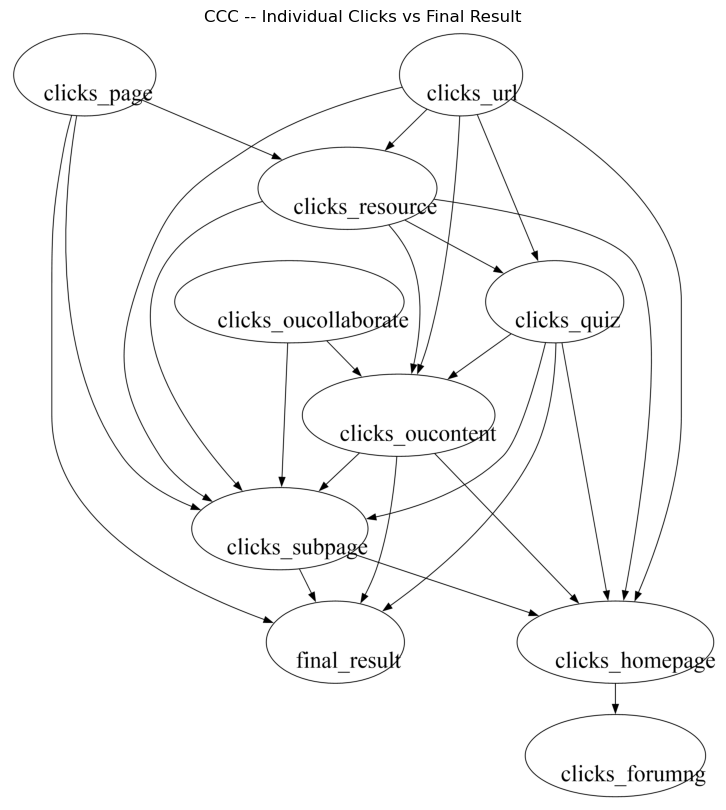

In [195]:
pyd3_ccc = GraphUtils.to_pydot(cg3_ccc.G, labels=node_names_dag3_ccc)

for node in pyd3_ccc.get_nodes():
    node.set_fontsize('20')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.30')

png_bytes3_ccc = pyd3_ccc.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\CCC_DAG3_clicks_vs_finalresult.png", "wb") as f:
    f.write(png_bytes3_ccc)

img3_ccc = mpimg.imread(io.BytesIO(png_bytes3_ccc), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img3_ccc)
plt.axis('off')
plt.title("CCC -- Individual Clicks vs Final Result")
plt.show()